# Тест без улучшений

In [2]:
import os
import sys
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
sys.path.append('/')
import sklearn.cluster as cluster
from skimage import measure as ms
from scipy.ndimage.morphology import binary_fill_holes
import numpy as np
import SimpleITK as sitk
import cv2 as cv
from skimage import morphology
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import matplotlib.gridspec as gridspec

## 1. Работа с данными

In [3]:
import os
import re
import shutil
from pathlib import Path

# === НАСТРОЙКИ ===
SOURCE_ROOT = r"C:\PKG - UPENN-GBM-NIfTI\UPENN-GBM\NIfTI-files"
IMAGES_DIR = os.path.join(SOURCE_ROOT, "images_structural")
MASKS_DIR = os.path.join(SOURCE_ROOT, "automated_segm")
OUTPUT_DIR = r"C:\PKG - UPENN-GBM-NIfTI\ready_for_split"  # сюда сложим подготовленные данные

# Модальности и соответствующие паттерны в именах файлов
MODALITIES = {
    't1': 'T1.nii.gz',      # обычный T1
    't1gd': 'T1GD.nii.gz',  # T1 с контрастом (Gadolinium)
    't2': 'T2.nii.gz',      # T2
    'flair': 'FLAIR.nii.gz' # FLAIR
}

# === 1. Находим всех пациентов с масками ===
print("Поиск пациентов с масками...")
patients_with_masks = set()

for mask_file in os.listdir(MASKS_DIR):
    if mask_file.endswith(".nii.gz"):
        # Извлекаем ID пациента из маски (например, UPENN-GBM-00001_11)
        match = re.match(r"(UPENN-GBM-\d+_\d+)", mask_file)
        if match:
            patients_with_masks.add(match.group(1))

print(f"Найдено пациентов с масками: {len(patients_with_masks)}")

# === 2. Создаем структуру для split-folders ===
print("\nСоздание структуры для split-folders...")

# Создаем папки для каждой модальности и для масок
for modality in MODALITIES.keys():
    os.makedirs(os.path.join(OUTPUT_DIR, modality), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'mask'), exist_ok=True)

processed = 0
missing_files = []

# === 3. Копируем файлы в соответствующие папки ===
for pid in patients_with_masks:
    patient_folder = os.path.join(IMAGES_DIR, pid)
    
    if not os.path.exists(patient_folder):
        print(f"Предупреждение: Нет папки для {pid}")
        continue
    
    # Копируем файлы модальностей
    for modality_name, modality_pattern in MODALITIES.items():
        # Ищем файл с точным совпадением паттерна
        found = False
        for file in os.listdir(patient_folder):
            if file.endswith(modality_pattern):
                src = os.path.join(patient_folder, file)
                dest = os.path.join(OUTPUT_DIR, modality_name, f"{pid}_{modality_name}.nii.gz")
                shutil.copy2(src, dest)
                found = True
                break
        
        if not found:
            missing_files.append(f"{pid} - не найден {modality_name}")
    
    # Копируем маску
    mask_src = None
    for mask_file in os.listdir(MASKS_DIR):
        if mask_file.startswith(pid) and "automated_approx_segm" in mask_file:
            mask_src = os.path.join(MASKS_DIR, mask_file)
            break
    
    if mask_src:
        dest_mask = os.path.join(OUTPUT_DIR, 'mask', f"{pid}_mask.nii.gz")
        shutil.copy2(mask_src, dest_mask)
        processed += 1
    else:
        missing_files.append(f"{pid} - не найдена маска")

# === 4. Выводим отчет ===
print(f"\n{'='*50}")
print(f"Обработано пациентов: {processed}")
print(f"Пациентов всего с масками: {len(patients_with_masks)}")

if missing_files:
    print(f"\nПропущенные файлы ({len(missing_files)}):")
    for missing in missing_files[:10]:  # покажем первые 10
        print(f"  - {missing}")
    if len(missing_files) > 10:
        print(f"  ... и еще {len(missing_files) - 10}")

# === 5. Проверяем итоговую структуру ===
print(f"\n{'='*50}")
print("Итоговая структура для split-folders:")
print(f"{OUTPUT_DIR}/")
for modality in MODALITIES.keys():
    modality_path = os.path.join(OUTPUT_DIR, modality)
    count = len(os.listdir(modality_path)) if os.path.exists(modality_path) else 0
    print(f"  {modality}/ - {count} файлов")

mask_path = os.path.join(OUTPUT_DIR, 'mask')
mask_count = len(os.listdir(mask_path)) if os.path.exists(mask_path) else 0
print(f"  mask/ - {mask_count} файлов")

# Проверяем, что количество файлов одинаковое для всех модальностей
print(f"\n{'='*50}")
print("Проверка целостности:")
file_counts = [len(os.listdir(os.path.join(OUTPUT_DIR, m))) for m in MODALITIES.keys()]
file_counts.append(mask_count)

if len(set(file_counts)) == 1:
    print(f"✓ Отлично! Все {file_counts[0]} пациентов имеют все 4 модальности и маски")
else:
    print("✗ Внимание! Количество файлов различается:")
    for i, modality in enumerate(list(MODALITIES.keys()) + ['mask']):
        print(f"  {modality}: {file_counts[i]}")

print("\n" + "="*50)
print("ГОТОВО! Теперь можно использовать split-folders:")
print("="*50)
print(f"\nУстановите split-folders (если еще не установлен):")
print("pip install split-folders")
print(f"\nЗапустите разделение датасета:")
print(f'split_folders --ratio 0.7 0.15 0.15 -- "{OUTPUT_DIR}" --output "C:\\PKG - UPENN-GBM-NIfTI\\splitted_dataset"')

Поиск пациентов с масками...
Найдено пациентов с масками: 611

Создание структуры для split-folders...

Обработано пациентов: 611
Пациентов всего с масками: 611

Итоговая структура для split-folders:
C:\PKG - UPENN-GBM-NIfTI\ready_for_split/
  t1/ - 611 файлов
  t1gd/ - 611 файлов
  t2/ - 611 файлов
  flair/ - 611 файлов
  mask/ - 611 файлов

Проверка целостности:
✓ Отлично! Все 611 пациентов имеют все 4 модальности и маски

ГОТОВО! Теперь можно использовать split-folders:

Установите split-folders (если еще не установлен):
pip install split-folders

Запустите разделение датасета:
split_folders --ratio 0.7 0.15 0.15 -- "C:\PKG - UPENN-GBM-NIfTI\ready_for_split" --output "C:\PKG - UPENN-GBM-NIfTI\splitted_dataset"


In [5]:
import splitfolders

inp_fold = r'C:\PKG - UPENN-GBM-NIfTI\ready_for_split'
out_fold = r'C:\PKG - UPENN-GBM-NIfTI\splitted_dataset'

splitfolders.ratio(inp_fold, output=out_fold, seed=1337, ratio=(.6, .2, .2), group_prefix=None)

Copying files: 3055 files [00:07, 430.65 files/s]


## 2. Эксперимент с кодом

Код из следующих трех клеток основан на алгоритме AUCseg(https://github.com/ZhaoBotee/AUCseg/tree/master)

In [3]:
def read_nii(path):
    nib_data = nib.load(path)
    img = nib_data.get_data()
    new_img = img.copy()
    affine = nib_data.affine.copy()
    hdr = nib_data.header.copy()
    return new_img, affine, hdr


def save_nii_sitk(arr, save_name):
    arr = np.swapaxes(arr, 0, 2)
    new_nii = sitk.GetImageFromArray(arr)
    sitk.WriteImage(new_nii, save_name)

In [4]:
def crop_img(img_arr, st, et):
    temp = img_arr.copy()
    return temp[st[0]:et[0], st[1]:et[1], st[2]:et[2]]


def clustering_img(img_arr_lists, num_clusters, chose_class='max', method='Kmeans'):
    X = np.zeros((img_arr_lists[0].size, len(img_arr_lists)))
    for idx, img_arr in enumerate(img_arr_lists):
        X[:, idx] = img_arr.flatten()

    if method == 'GMM':
        gmm = GaussianMixture(n_components=num_clusters, random_state=0).fit(X)
        if chose_class == 'max':
            temp_label = np.zeros(img_arr_lists[0].size)
            temp_label[gmm.predict(X) == np.argmax(gmm.means_)] = 1
            return np.reshape(temp_label, img_arr.shape)
        else:
            raise ValueError('have not implement this method!')

    else:
        raise Exception('this clustering method did not contained in our model.')


def get_bbox(img_arr, ):
    index_info = np.nonzero(img_arr)
    if len(img_arr.shape) < 3:
        st = [np.max([np.min(index_info[0]), 0]), np.max([np.min(index_info[1]), 0])]
        et = [np.min([np.max(index_info[0]), img_arr.shape[0]]), np.min([np.max(index_info[1]), img_arr.shape[1]])]
    elif len(img_arr.shape) == 3:
        st = [np.max([np.min(index_info[0]), 0]), np.max([np.min(index_info[1]), 0]),
              np.max([np.min(index_info[2]), 0])]
        et = [np.min([np.max(index_info[0]), img_arr.shape[0]]), np.min([np.max(index_info[1]), img_arr.shape[1]]),
              np.min([np.max(index_info[2]), img_arr.shape[2]])]
    else:
        raise ValueError('ERROR: we just support 2d or 3d image!')
    return st, et


def normalize_0_1(img_arr, min_intensity=None, max_intensity=None, ):
    if min_intensity is None:
        min_intensity = np.min(img_arr)
    if max_intensity is None:
        max_intensity = np.max(img_arr)
    img_arr[img_arr > max_intensity] = max_intensity
    img_arr[img_arr < min_intensity] = min_intensity
    return (img_arr - min_intensity) / max_intensity


def rm_small_cc(mask_array, rate=0.3):
    sitk_mask_img = sitk.GetImageFromArray(mask_array)
    cc = sitk.ConnectedComponent(sitk_mask_img)
    stats = sitk.LabelIntensityStatisticsImageFilter()
    stats.SetGlobalDefaultNumberOfThreads(8)
    stats.Execute(cc, sitk_mask_img)

    max_label = 0
    maxsize = 0
    for l in stats.GetLabels():
        size = stats.GetPhysicalSize(l)
        if maxsize < size:
            max_label = l
            maxsize = size

    not_remove = []
    for l in stats.GetLabels():
        size = stats.GetPhysicalSize(l)
        if size > maxsize * rate:
            not_remove.append(l)
    label_img = sitk.GetArrayFromImage(cc)
    out_mask = label_img.copy()
    out_mask[label_img != max_label] = 0

    for i in range(len(not_remove)):
        out_mask[label_img == not_remove[i]] = 1
    return out_mask


def crop2raw(raw_shape, new_img, st, et):
    temp = np.zeros(raw_shape)
    temp[st[0]:et[0], st[1]:et[1], st[2]:et[2]] = new_img
    return temp


def segment_necrotic(data, kernel_size, connec, ):
    kernel = np.ones((kernel_size, kernel_size, kernel_size))
    enhance_data = morphology.dilation(data, kernel)  # dilation to make sure that ec tumor is a cc.
    [heart_res, num] = ms.label(enhance_data, background=-1, connectivity=connec, return_num=True)
    areas = []
    region = ms.regionprops(heart_res)
    for i in range(num):
        areas.append(region[i].area)
    index = np.argsort(-np.array(areas))
    label_num1 = index[0] + 1
    necrotic = np.ones(data.shape)
    necrotic[heart_res == label_num1] = 0
    necrotic[enhance_data == 1] = 0
    necrotic = morphology.dilation(necrotic, kernel)
    return necrotic


def fill_full(data):
    c = np.ones((3, 3, 3))
    # dilation
    data = morphology.dilation(data, c)
    # find cc
    [heart_res, num] = ms.label(data, connectivity=3, background=-1, return_num=True)
    areas = []
    # fill the hole
    region = ms.regionprops(heart_res)
    for i in range(num):
        areas.append(region[i].area)
    label_num = np.argsort(-np.array(areas))
    for i in label_num[1:]:
        data[heart_res == (i + 1)] = 1
    return data

In [5]:
def seg_pipeline(t1ce_dir, flair_dir, save_dir, bbox=None, nc_seg_mode='cc', t2_dir=None, t2_cluster=3, f_cluster=5,
                 ec_cluster=4,
                 c_method='Kmeans', ):
    assert os.path.isfile(t1ce_dir), print('There is not a file at %s' % t1ce_dir)
    assert os.path.isfile(flair_dir), print('There is not a file at %s' % flair_dir)
    t1ce_img, affine_t1ce, hdr_t1ce = read_nii(t1ce_dir)
    flair_img, affine_flair, hdr_flair = read_nii(flair_dir)
    if bbox is not None:
        st1, et1 = bbox[0], bbox[1]
    else:
        st1, et1 = get_bbox(flair_img)

    flair_roi = normalize_0_1(crop_img(flair_img, st1, et1))

    full_tumor = clustering_img([flair_roi], int(f_cluster), method=c_method)
    full_tumor = rm_small_cc(full_tumor.astype(np.uint8), rate=0.3)
    full_tumor = fill_full(full_tumor)
    st_2, et_2 = get_bbox(full_tumor)
    full_tumor_roi = crop_img(full_tumor, st_2, et_2)

    # ec tumor segmentation
    t1ce_roi = normalize_0_1(crop_img(crop_img(t1ce_img, st1, et1), st_2, et_2))
    t1ce_roi[full_tumor_roi != 1] = 0
    ec_tumor = clustering_img([t1ce_roi, ], int(ec_cluster), method=c_method)

    # necrotic segmentation
    if nc_seg_mode == 'cc':
        nc_tumor = segment_necrotic(ec_tumor, 3, 1)
        # integrate mask
        final_mask = np.zeros(full_tumor_roi.shape)
        final_mask[full_tumor_roi == 1] = 2
        final_mask[ec_tumor == 1] = 4
        final_mask[nc_tumor == 1] = 1
    elif nc_seg_mode == 't2':
        # core segmentation
        assert os.path.isfile(t2_dir), print('There is not a file at %s' % t2_dir)
        t2_img, affine_t2, hdr_t2 = read_nii(t2_dir)
        t2_roi = normalize_0_1(crop_img(crop_img(t2_img, st1, et1), st_2, et_2))
        t2_roi[full_tumor_roi != 1] = 0
        core_tumor = clustering_img([t2_roi, ], int(t2_cluster), method=c_method)
        # integrate mask
        final_mask = np.zeros(full_tumor_roi.shape)
        final_mask[full_tumor_roi == 1] = 2
        final_mask[core_tumor == 1] = 1
        final_mask[ec_tumor == 1] = 4
    else:
        raise Exception('This necrotic region segmentation method have not been defined!')
    final_mask = crop2raw(flair_img.shape, crop2raw(full_tumor.shape, final_mask, st_2, et_2), st1,
                                    et1)
    if save_dir is not None:
        save_nii_sitk(final_mask, save_dir)
    return final_mask

In [6]:
def extract_gt_subregions(seg_data):
    wt = seg_data > 0
    tc = (seg_data == 1) | (seg_data == 4)
    et = (seg_data == 4)
    return wt, tc, et

def extract_pred_subregions(pred_mask):
    wt = pred_mask > 0
    tc = (pred_mask == 1) | (pred_mask == 4)
    et = (pred_mask == 4)
    return wt, tc, et

def dice_score(pred, gt):
    pred_bool = pred.astype(bool)
    gt_bool = gt.astype(bool)
    intersection = np.logical_and(pred_bool, gt_bool).sum()
    if pred_bool.sum() + gt_bool.sum() == 0:
        return 1.0
    return 2.0 * intersection / (pred_bool.sum() + gt_bool.sum())


data_root = 'C:/PKG - UPENN-GBM-NIfTI/splitted_dataset/test'

flair_dir = os.path.join(data_root, 'flair')
t1ce_dir = os.path.join(data_root, 't1gd')
t2_dir = os.path.join(data_root, 't2')
mask_dir = os.path.join(data_root, 'mask')

output_dir = os.path.join(data_root, 'predictions_aucseg')
os.makedirs(output_dir, exist_ok=True)

# Параметры AUCseg (как в их примерах)
FC = 5           # n_cluster1
EC = 3           # n_cluster2
T2_N = 3         # n_cluster3
NC_SEG_MODE = 'cc'  # 'cc' или 't2'
CLUSTER_METHOD = 'GMM'

flair_files = [f for f in os.listdir(flair_dir) if f.endswith('.nii.gz')]
patient_ids = [f.replace('_flair.nii.gz', '') for f in flair_files]
print(f"Найдено пациентов: {len(patient_ids)}")

results = []

for patient_id in tqdm(patient_ids, desc="Processing"):
    flair_path = os.path.join(flair_dir, f"{patient_id}_flair.nii.gz")
    t1ce_path = os.path.join(t1ce_dir, f"{patient_id}_t1gd.nii.gz")
    t2_path = os.path.join(t2_dir, f"{patient_id}_t2.nii.gz")
    mask_path = os.path.join(mask_dir, f"{patient_id}_mask.nii.gz")
    pred_save_path = os.path.join(output_dir, f"{patient_id}_pred.nii.gz")
    
    if not all(os.path.exists(p) for p in [flair_path, t1ce_path, t2_path, mask_path]):
        print(f"Warning: {patient_id} missing files")
        continue
    
    try:
        # ЗАПУСК ОРИГИНАЛЬНОЙ seg_pipeline ИЗ AUCseg
        seg_pipeline(
            t1ce_dir=t1ce_path,
            flair_dir=flair_path,
            save_dir=pred_save_path,
            f_cluster=FC,
            ec_cluster=EC,
            c_method=CLUSTER_METHOD,
            bbox=None,
            nc_seg_mode=NC_SEG_MODE,
            t2_dir=t2_path,
            t2_cluster=T2_N
        )
        
        # Загрузка предсказания и GT
        pred_mask = read_nii(pred_save_path)[0]
        gt_data = read_nii(mask_path)[0].astype(np.uint8)
        
        if pred_mask.shape != gt_data.shape:
            print(f"Shape mismatch: {patient_id}")
            continue
        
        # Субрегионы
        gt_wt, gt_tc, gt_et = extract_gt_subregions(gt_data)
        pred_wt, pred_tc, pred_et = extract_pred_subregions(pred_mask)
        
        # Dice
        dice_wt = dice_score(pred_wt, gt_wt)
        dice_tc = dice_score(pred_tc, gt_tc)
        dice_et = dice_score(pred_et, gt_et)
        
        results.append((patient_id, dice_wt, dice_tc, dice_et))
        
    except Exception as e:
        print(f"Error {patient_id}: {e}")

if results:
    wt_scores = [r[1] for r in results]
    tc_scores = [r[2] for r in results]
    et_scores = [r[3] for r in results]
    
    # Вычисляем стандартные отклонения
    wt_std = np.std(wt_scores)
    tc_std = np.std(tc_scores)
    et_std = np.std(et_scores)
    
    print(f"Patients: {len(results)}")
    print(f"\nWT Dice: mean={np.mean(wt_scores):.4f} ± {wt_std:.4f}, median={np.median(wt_scores):.4f}, success={sum(d>=0.5 for d in wt_scores)}/{len(results)}")
    print(f"TC Dice: mean={np.mean(tc_scores):.4f} ± {tc_std:.4f}, median={np.median(tc_scores):.4f}, success={sum(d>=0.5 for d in tc_scores)}/{len(results)}")
    print(f"ET Dice: mean={np.mean(et_scores):.4f} ± {et_std:.4f}, median={np.median(et_scores):.4f}, success={sum(d>=0.5 for d in et_scores)}/{len(results)}")

Processing:   0%|                                                                              | 0/122 [00:00<?, ?it/s]

Найдено пациентов: 122


Processing: 100%|████████████████████████████████████████████████████████████████████| 122/122 [27:21<00:00, 13.45s/it]

Patients: 122

WT Dice: mean=0.7721 ± 0.2092, median=0.8525, success=110/122
TC Dice: mean=0.6329 ± 0.2601, median=0.6593, success=91/122
ET Dice: mean=0.6946 ± 0.2471, median=0.7750, success=100/122


### Визуализация

In [17]:
def visualize_best_worst(results, data_root, output_dir, n_show=3, save_plots=False):

    metrics = {
        'WT': 1,
        'TC': 2,
        'ET': 3
    }

    if save_plots:
        viz_dir = os.path.join(output_dir, 'viz')
        os.makedirs(viz_dir, exist_ok=True)

    for metric_name, idx in metrics.items():
        print(f"\n--- Visualizing Best/Worst for {metric_name} ---")
        
        # Сортируем по текущей метрике
        sorted_results = sorted(results, key=lambda x: x[idx], reverse=True)
        
        best_cases = sorted_results[:n_show]
        worst_cases = sorted_results[-n_show:][::-1] 
        
        cases_to_vis = [('Best', c) for c in best_cases] + [('Worst', c) for c in worst_cases]
        
        # Настройка плота: 4 колонки
        fig = plt.figure(figsize=(20, 5 * len(cases_to_vis)))
        gs = gridspec.GridSpec(len(cases_to_vis), 4, wspace=0.1, hspace=0.3)
        
        for row_idx, (case_type, res_tuple) in enumerate(cases_to_vis):
            patient_id, dice_wt, dice_tc, dice_et = res_tuple
            current_dice = [dice_wt, dice_tc, dice_et][idx-1]
            
            # Пути
            flair_path = os.path.join(data_root, 'flair', f"{patient_id}_flair.nii.gz")
            t1ce_path = os.path.join(data_root, 't1gd', f"{patient_id}_t1gd.nii.gz")
            mask_path = os.path.join(data_root, 'mask', f"{patient_id}_mask.nii.gz")
            pred_path = os.path.join(output_dir, f"{patient_id}_pred.nii.gz")
            
            try:
                # Читаем данные
                flair_img, _, _ = read_nii(flair_path)
                t1ce_img, _, _ = read_nii(t1ce_path)
                gt_mask, _, _ = read_nii(mask_path)
                pred_mask, _, _ = read_nii(pred_path)
                
                # Выбор среза: ищем срез с максимальным объемом WT в GT
                # (можно менять логику выбора среза под конкретную метрику, но WT обычно универсален)
                wt_gt_binary = gt_mask > 0
                slice_sums = np.sum(wt_gt_binary, axis=(0, 1))
                
                if np.max(slice_sums) == 0:
                    mid_slice = flair_img.shape[2] // 2
                else:
                    mid_slice = np.argmax(slice_sums)
                
                # Извлекаем срезы
                flair_slice = flair_img[:, :, mid_slice]
                t1ce_slice = t1ce_img[:, :, mid_slice]
                gt_slice = gt_mask[:, :, mid_slice]
                pred_slice = pred_mask[:, :, mid_slice]
                
                # Нормализация изображений для отображения
                def normalize_img(img):
                    p99 = np.percentile(img[img > 0], 99) if np.any(img > 0) else np.percentile(img, 99)
                    if p99 == 0: p99 = 1
                    return np.clip(img, 0, p99) / p99

                flair_disp = normalize_img(flair_slice)
                t1ce_disp = normalize_img(t1ce_slice)
                
                # --- Отрисовка ---
                
                # 1. T1GD (T1 с контрастом)
                ax1 = fig.add_subplot(gs[row_idx, 0])
                ax1.imshow(t1ce_disp, cmap='gray')
                ax1.set_title(f"T1 МРТ с контрастом\n{case_type} {metric_name} Dice: {current_dice:.3f}", fontsize=10)
                ax1.axis('off')
                
                # 2. FLAIR
                ax2 = fig.add_subplot(gs[row_idx, 1])
                ax2.imshow(flair_disp, cmap='gray')
                ax2.set_title("FLAIR МРТ", fontsize=10)
                ax2.axis('off')
                
                # 3. Ground Truth Mask (Дефолтная карта)
                ax3 = fig.add_subplot(gs[row_idx, 2])
                ax3.imshow(gt_slice, interpolation='nearest') 
                ax3.set_title("Истинная маска", fontsize=10)
                ax3.axis('off')
                
                # 4. Predicted Mask (Дефолтная карта)
                ax4 = fig.add_subplot(gs[row_idx, 3])
                ax4.imshow(pred_slice, interpolation='nearest')
                ax4.set_title("Предсказанная маска", fontsize=10)
                ax4.axis('off')

            except Exception as e:
                print(f"Could not visualize {patient_id}: {e}")
                import traceback
                traceback.print_exc()
                
        plt.suptitle(f"Best and Worst Cases for {metric_name} Segmentation", fontsize=16, y=1.01)
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(os.path.join(viz_dir, f"best_worst_{metric_name}.png"), dpi=150, bbox_inches='tight')
            
        plt.show()
        plt.close()


--- Visualizing Best/Worst for WT ---


C:\Users\Dmitry\AppData\Local\Temp\ipykernel_13116\1762239077.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


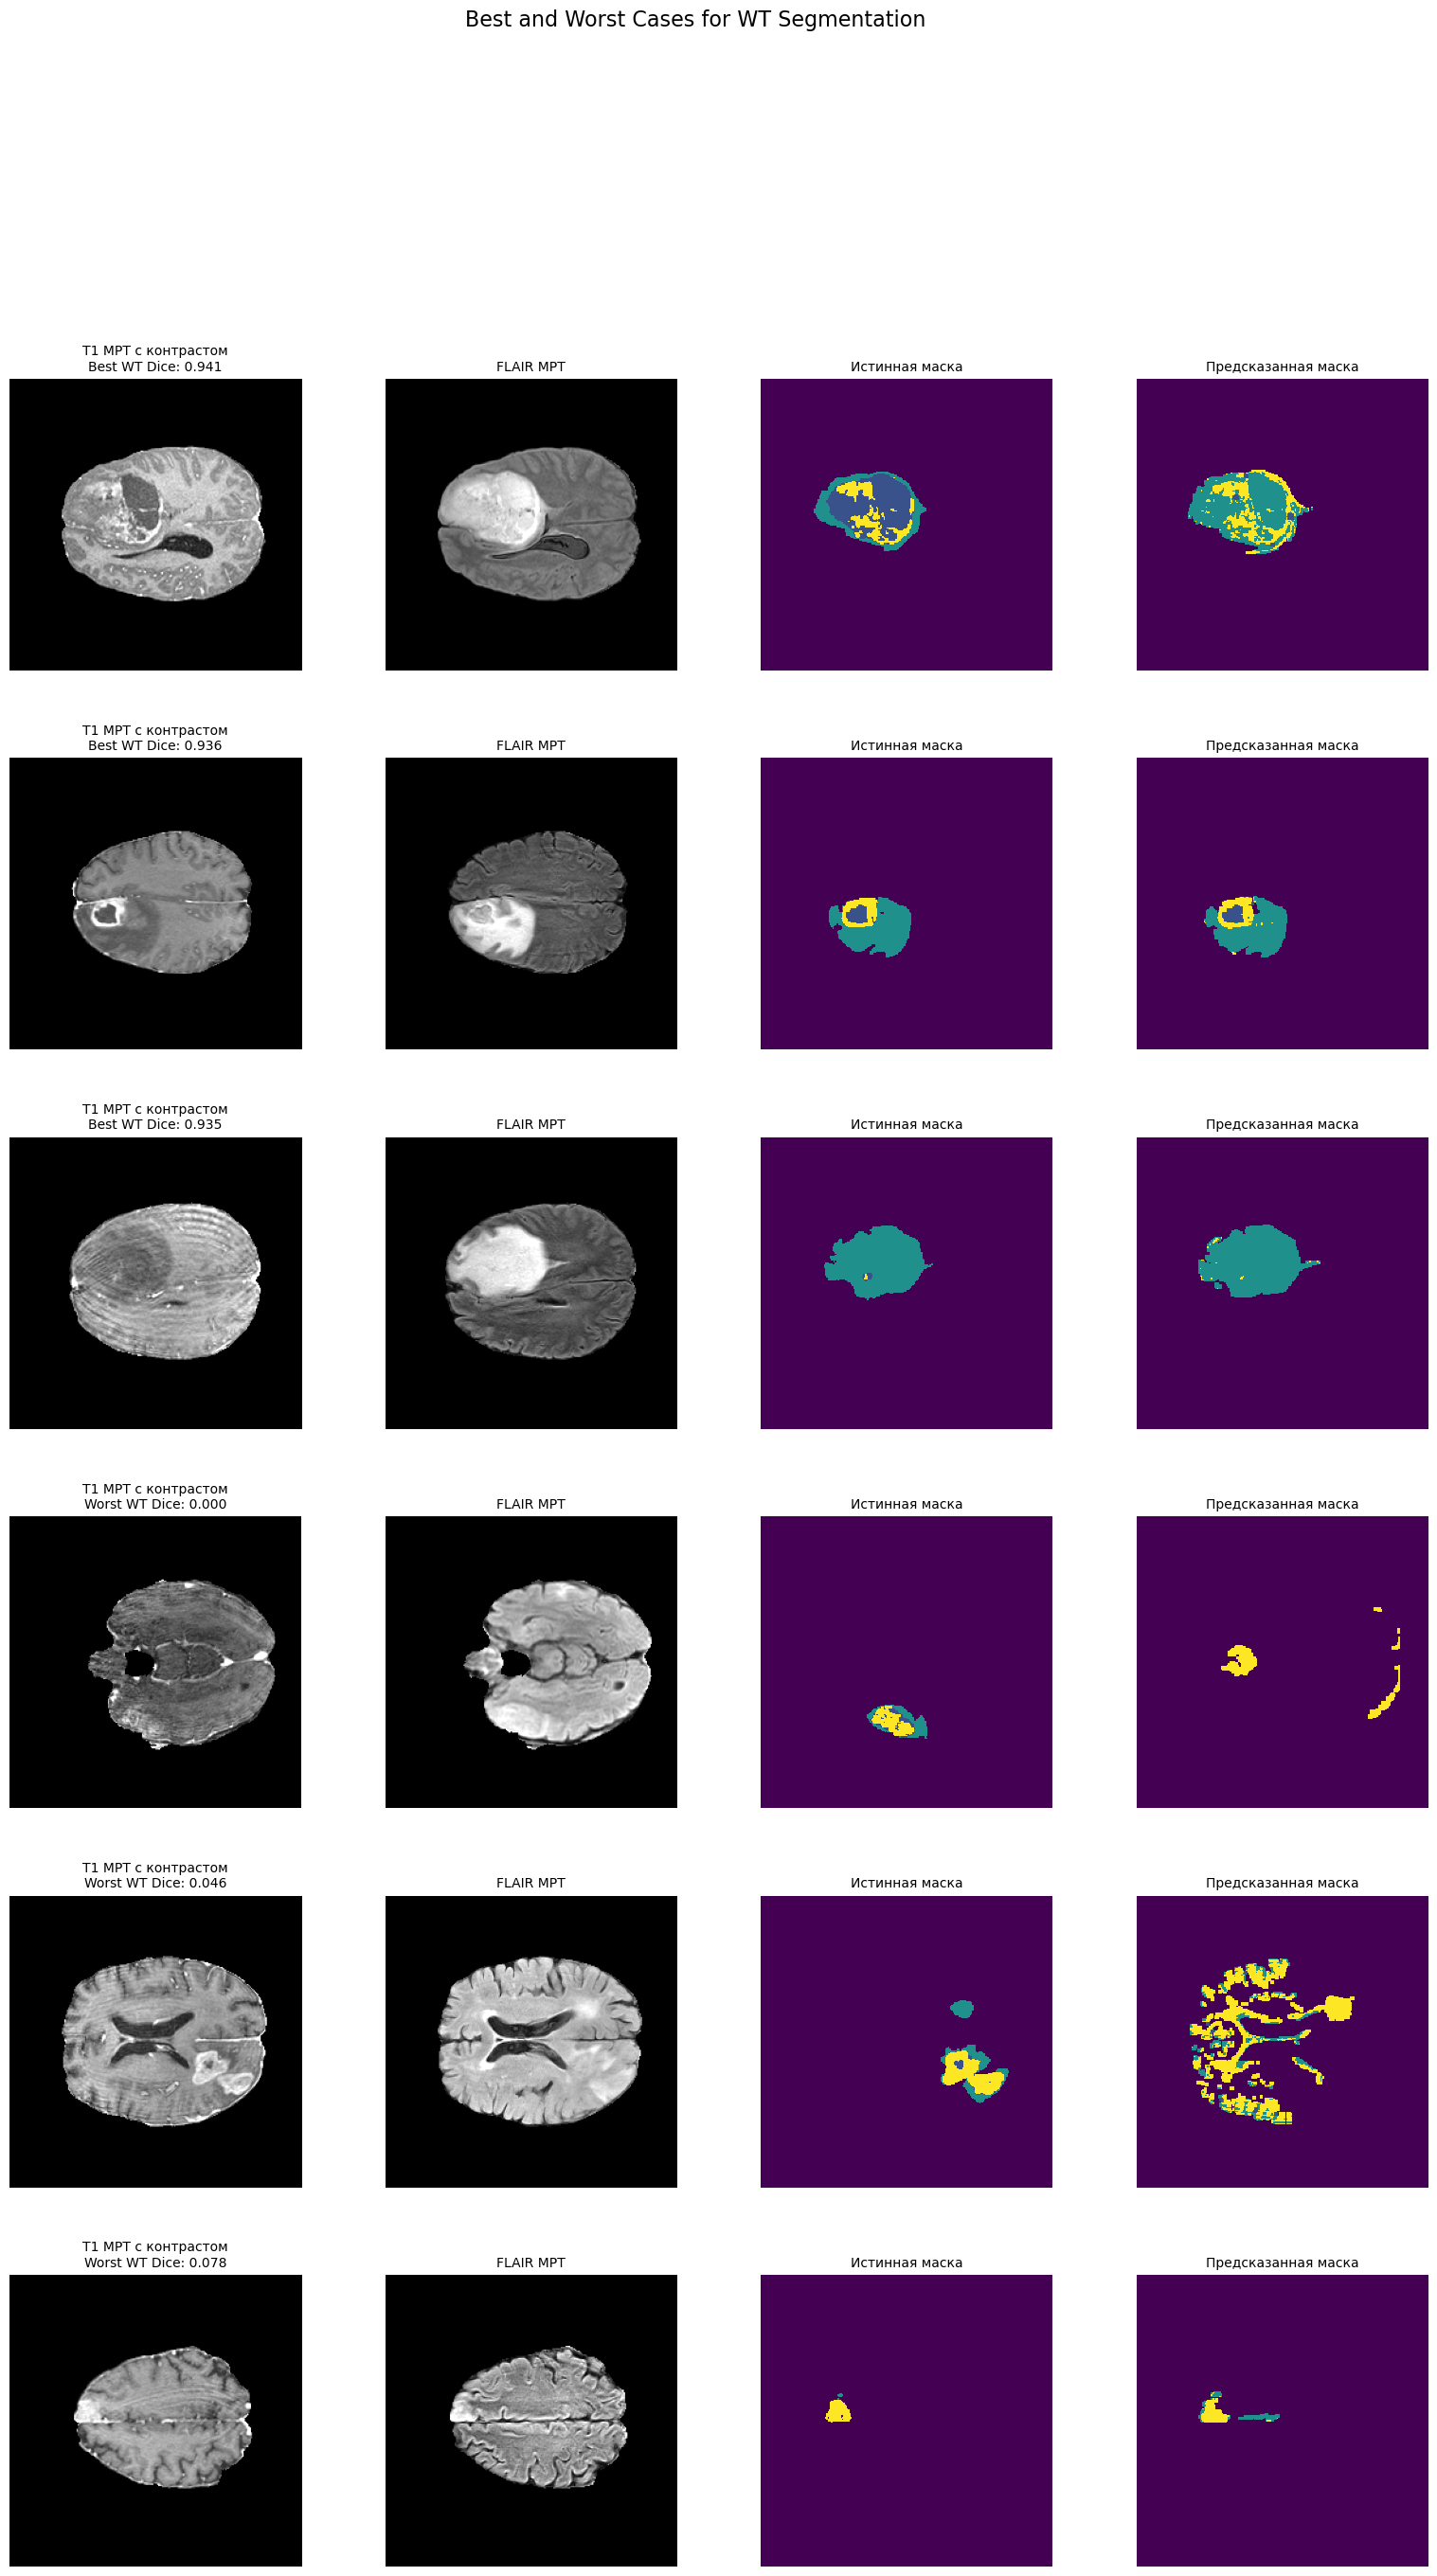


--- Visualizing Best/Worst for TC ---


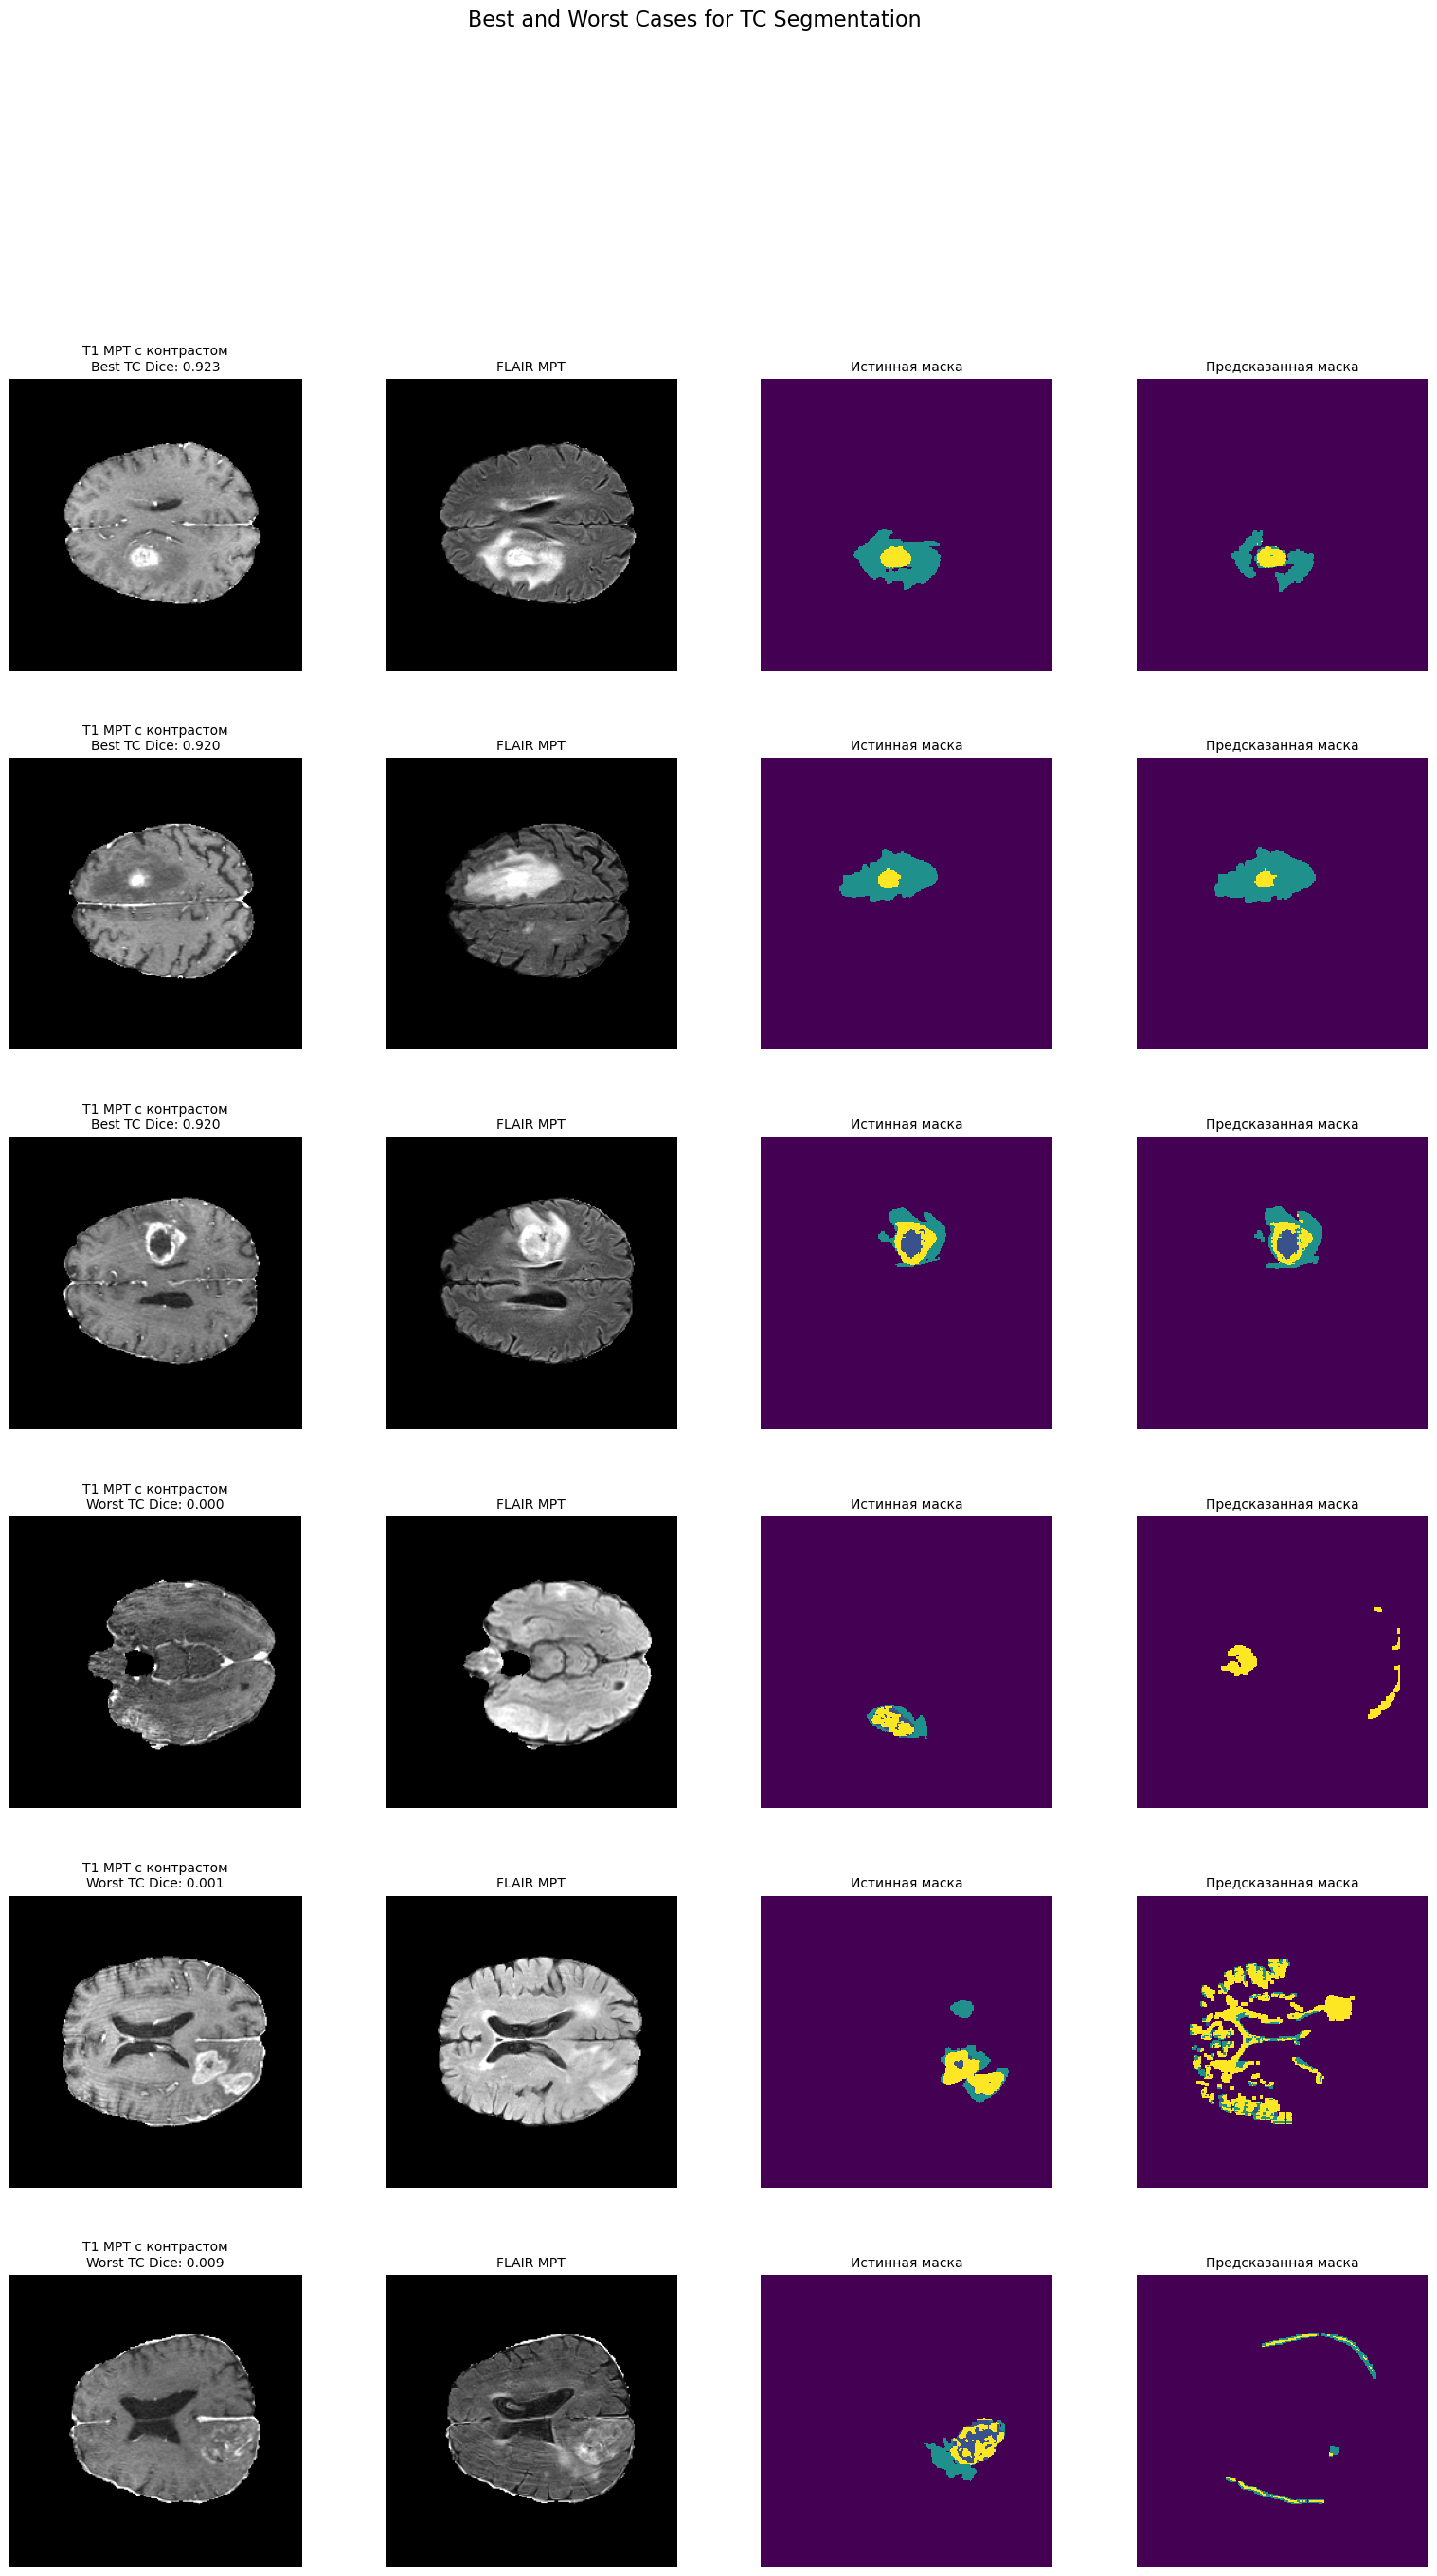


--- Visualizing Best/Worst for ET ---


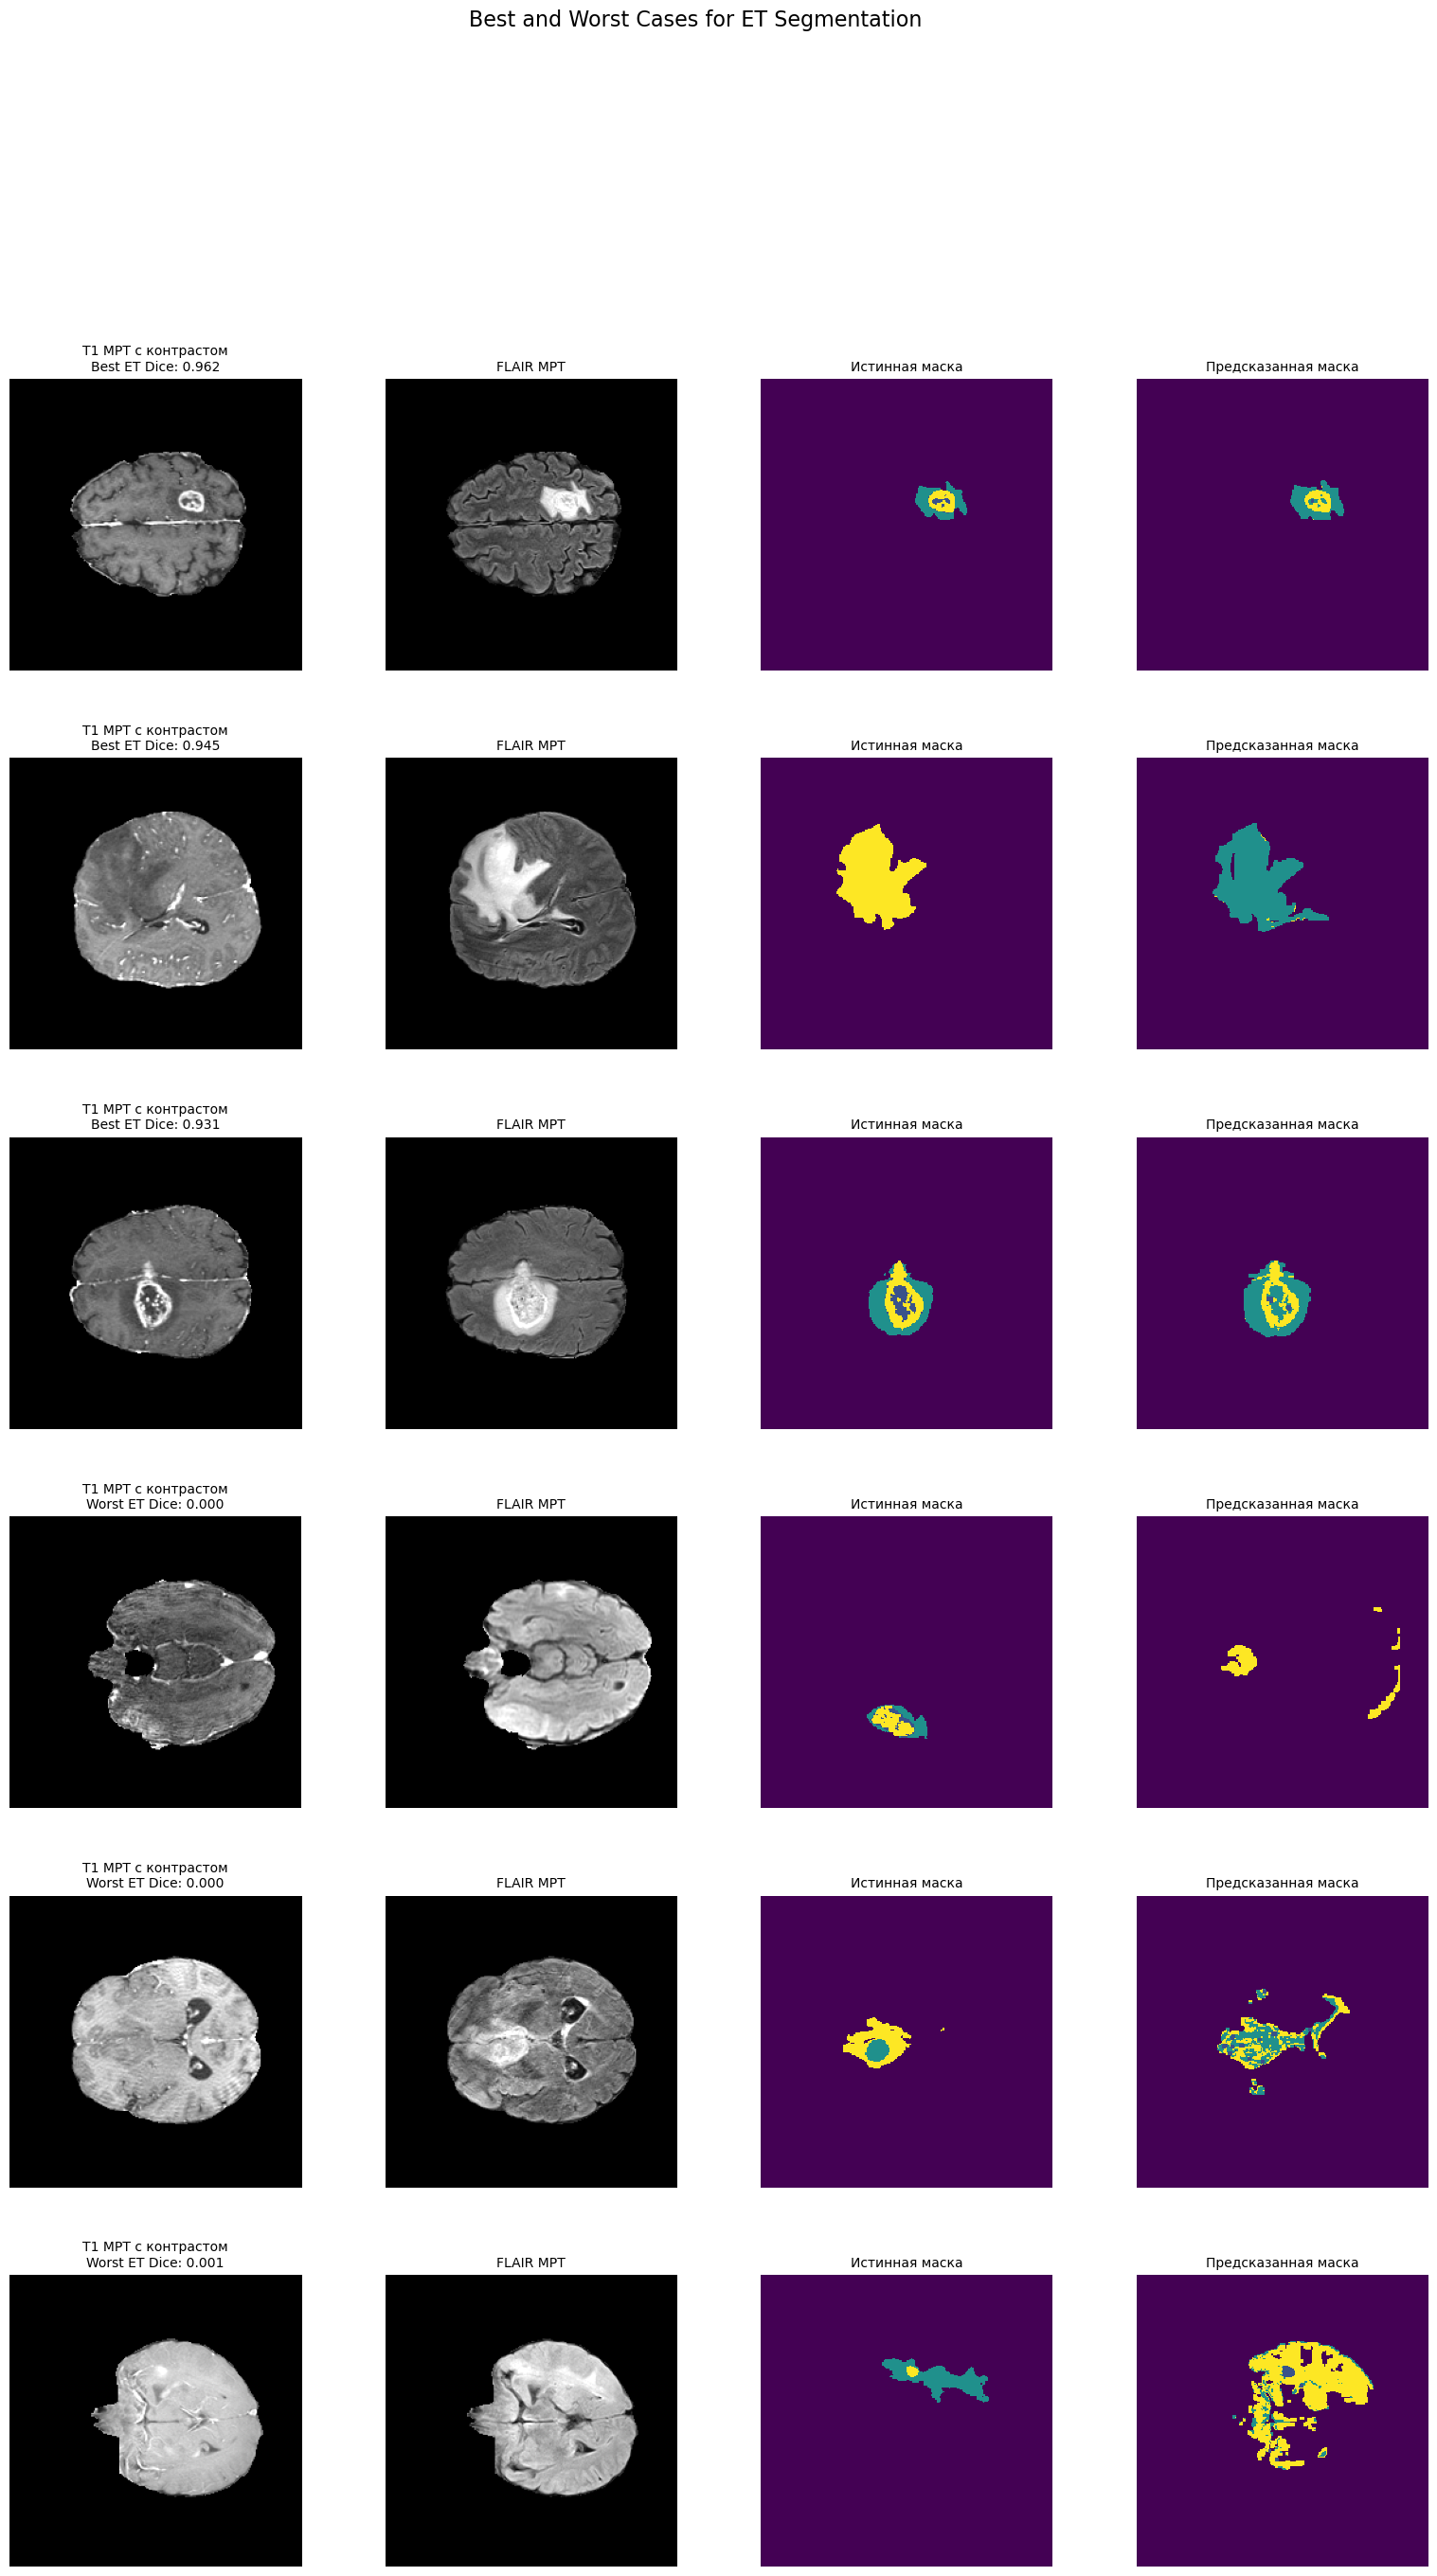

In [18]:
visualize_best_worst(results, data_root, output_dir, n_show=3)